In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [21]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/PIA/Incendios/dataset_incendios_perpignan_3clases.csv')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   aire             3654 non-null   float64
 1   tiempo           3654 non-null   float64
 2   humedad          3654 non-null   float64
 3   alerta_incendio  3654 non-null   object 
dtypes: float64(3), object(1)
memory usage: 114.3+ KB


## Fase 1: Preparación Técnica y Refinamiento (Preprocessing)

### Codificación de Variable Objetivo (Alerta_Incendio)

In [23]:
df['alerta_incendio'].value_counts()

,count
alerta_incendio,
Baja,2137
Moderada,1407
Alta,110


In [24]:
codificacion = {'Baja': 0, 'Moderada': 1, 'Alta': 2}

diccionario_inverso = {v: k for k, v in codificacion.items()}

df['alerta_incendio'] = df['alerta_incendio'].map(codificacion)

df['alerta_incendio'].value_counts()

,count
alerta_incendio,
0,2137
1,1407
2,110


In [25]:
X = df[['aire', 'tiempo', 'humedad']]
y = df['alerta_incendio']

### Partición Estratificada

In [26]:
# El parámetro stratify=y asegura que el ~3% de casos "Alta" se mantenga proporcional


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Escalado de variables

In [27]:
scaler = StandardScaler()

# Es vital hacer fit_transform SOLO en el conjunto de entrenamiento
# para evitar que información del conjunto de prueba se "filtre" (data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Al conjunto de prueba solo se le aplica transform()
X_test_scaled = scaler.transform(X_test)

In [28]:
# (Opcional) Convertimos de nuevo a DataFrame para que sea más fácil de visualizar
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [29]:
# Comprobación rápida de los resultados
print("=== Resumen de la Fase 1 ===")
print(f"Tamaño total del dataset: {df.shape[0]} filas")
print(f"Set de Entrenamiento: {X_train_scaled.shape[0]} filas")
print(f"Set de Prueba: {X_test_scaled.shape[0]} filas\n")

print("Distribución de clases en Entrenamiento:")
print(y_train.value_counts(normalize=True).apply(lambda x: f"{x:.2%}"), "\n")

print("Distribución de clases en Prueba:")
print(y_test.value_counts(normalize=True).apply(lambda x: f"{x:.2%}"), "\n")

print("Muestra de datos escalados (X_train):")
print(X_train_scaled.head())

=== Resumen de la Fase 1 ===
Tamaño total del dataset: 3654 filas
Set de Entrenamiento: 2923 filas
Set de Prueba: 731 filas

Distribución de clases en Entrenamiento:
alerta_incendio
0    58.47%
1    38.52%
2     3.01%
Name: proportion, dtype: object 

Distribución de clases en Prueba:
alerta_incendio
0    58.55%
1    38.44%
2     3.01%
Name: proportion, dtype: object 

Muestra de datos escalados (X_train):
       aire    tiempo   humedad
0 -1.077977 -0.359675  0.856428
1  0.122801 -0.472361  0.588942
2  0.380110 -0.772859  0.388327
3 -1.335286  3.321422 -1.350336
4  0.951909 -0.960670  0.990172


## Fase 2: Gestión del Desbalanceo

¿Cuál elegir?
Usa SMOTE si vas a utilizar Redes Neuronales o KNN, ya que estos algoritmos suelen funcionar mejor teniendo muestras físicas de cada clase.

Usa Pesos de Clase si vas a usar Árboles de Decisión, Random Forest, o Regresión Logística, ya que gestionan internamente el balance con el parámetro class_weight='balanced' de forma más eficiente y sin crear datos ficticios.

In [30]:
# Para la Opción 1: SMOTE
#from imblearn.over_sampling import SMOTE

# Para la Opción 2: Pesos de Clase
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

## Opción SMOTE

In [31]:
#print("Distribución original antes de SMOTE:")
#print(y_train.value_counts())

# Inicializamos SMOTE con semilla aleatoria para reproducibilidad
#smote = SMOTE(random_state=42)

# Solo aplicamos SMOTE a los datos de entrenamiento (¡NUNCA al test!)
#X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

#print("\nDistribución después de SMOTE:")
#print(y_train_smote.value_counts())

### Opción Class Weight

In [32]:
# Calculamos automáticamente cuánto debe "pesar" cada clase para estar balanceadas
clases = np.unique(y_train)
pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases,
    y=y_train
)

# Lo convertimos a un diccionario (que es lo que le gustará a tu modelo más tarde)
pesos_diccionario = dict(zip(clases, pesos))

print("Pesos asignados a cada clase:")
for clase, peso in pesos_diccionario.items():
    nombre_clase = diccionario_inverso[clase] # Usamos el diccionario de la Fase 1 ("Baja", "Alta")
    print(f"Clase {clase} ({nombre_clase}): Multiplicador de peso = {peso:.2f}")

Pesos asignados a cada clase:
Clase 0 (Baja): Multiplicador de peso = 0.57
Clase 1 (Moderada): Multiplicador de peso = 0.87
Clase 2 (Alta): Multiplicador de peso = 11.07


## Fase 3: Entrenamiento y Selección de Modelos

In [33]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

In [34]:
# ==========================================
# MODELO 1: ÁRBOL DE DECISIÓN SIMPLE (Para Reglas Manuales)
# ==========================================
# Usamos max_depth=3 para que el árbol no crezca demasiado y sea interpretable por humanos.
# OJO: Para este modelo usamos X_train (sin escalar), ¡para que las reglas mantengan sus valores reales (grados, %, km/h)!
arbol_simple = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
arbol_simple.fit(X_train, y_train)

y_pred_arbol = arbol_simple.predict(X_test)

print("--- MODELO 1: Árbol de Decisión de Reglas Simples ---")
print("Reglas generadas (para el equipo de Protección Civil):")
# Extraemos las reglas en formato texto
reglas = export_text(arbol_simple, feature_names=list(X.columns))
# Sustituimos los números por las etiquetas para que sea legible
reglas = reglas.replace("class: 0", "ALERTA BAJA")
reglas = reglas.replace("class: 1", "ALERTA MODERADA")
reglas = reglas.replace("class: 2", "ALERTA ALTA")
print(reglas)
print("\nReporte de Clasificación (Árbol Simple):")
print(classification_report(y_test, y_pred_arbol, target_names=['Baja', 'Moderada', 'Alta']))

--- MODELO 1: Árbol de Decisión de Reglas Simples ---
Reglas generadas (para el equipo de Protección Civil):
|--- humedad <= 0.55
|   |--- aire <= 26.25
|   |   |--- humedad <= 0.39
|   |   |   |--- ALERTA ALTA
|   |   |--- humedad >  0.39
|   |   |   |--- ALERTA MODERADA
|   |--- aire >  26.25
|   |   |--- tiempo <= 5.05
|   |   |   |--- ALERTA ALTA
|   |   |--- tiempo >  5.05
|   |   |   |--- ALERTA ALTA
|--- humedad >  0.55
|   |--- humedad <= 0.69
|   |   |--- aire <= 26.05
|   |   |   |--- ALERTA BAJA
|   |   |--- aire >  26.05
|   |   |   |--- ALERTA MODERADA
|   |--- humedad >  0.69
|   |   |--- aire <= 32.05
|   |   |   |--- ALERTA BAJA
|   |   |--- aire >  32.05
|   |   |   |--- ALERTA MODERADA


Reporte de Clasificación (Árbol Simple):
              precision    recall  f1-score   support

        Baja       0.89      0.98      0.93       428
    Moderada       0.95      0.56      0.71       281
        Alta       0.24      1.00      0.39        22

    accuracy              

In [35]:
# ==========================================
# MODELO 2: RANDOM FOREST (El estándar confiable)
# ==========================================
# Configuramos class_weight='balanced' directamente en el modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Aquí SÍ usamos los datos escalados de la Fase 1
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("\n--- MODELO 2: Random Forest ---")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['Baja', 'Moderada', 'Alta']))


--- MODELO 2: Random Forest ---
Reporte de Clasificación:
              precision    recall  f1-score   support

        Baja       1.00      1.00      1.00       428
    Moderada       0.97      1.00      0.99       281
        Alta       1.00      0.68      0.81        22

    accuracy                           0.99       731
   macro avg       0.99      0.89      0.93       731
weighted avg       0.99      0.99      0.99       731



In [36]:
# ==========================================
# MODELO 3: GRADIENT BOOSTING (Equivalente a LightGBM/XGBoost)
# ==========================================
# Para este algoritmo, calculamos los pesos de muestra de forma explícita
pesos_muestras = compute_sample_weight(class_weight='balanced', y=y_train)

# HistGradientBoosting no acepta "class_weight" en el constructor, sino durante el entrenamiento (fit)
gb_model = HistGradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train, sample_weight=pesos_muestras)

y_pred_gb = gb_model.predict(X_test_scaled)

print("\n--- MODELO 3: Hist Gradient Boosting ---")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_gb, target_names=['Baja', 'Moderada', 'Alta']))


--- MODELO 3: Hist Gradient Boosting ---
Reporte de Clasificación:
              precision    recall  f1-score   support

        Baja       1.00      1.00      1.00       428
    Moderada       1.00      1.00      1.00       281
        Alta       1.00      0.95      0.98        22

    accuracy                           1.00       731
   macro avg       1.00      0.98      0.99       731
weighted avg       1.00      1.00      1.00       731



## Fase 4: Evaluación con Enfoque en Prevención

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

In [42]:
# 1. PREDICCIONES ESTÁNDAR Y PROBABILIDADES
y_pred_estandar = gb_model.predict(X_test_scaled)
# Obtenemos el % de probabilidad que el modelo asignó a cada clase [Baja, Moderada, Alta]
y_proba = gb_model.predict_proba(X_test_scaled)

# ==========================================
# ANÁLISIS 1: MATRIZ DE CONFUSIÓN (Umbral Estándar)
# ==========================================
print("--- 1. MATRIZ DE CONFUSIÓN (ESTÁNDAR) ---")
cm = confusion_matrix(y_test, y_pred_estandar)
etiquetas = ['Baja', 'Moderada', 'Alta']

# Mostramos la matriz en texto (puedes descomentar la visualización gráfica si usas Jupyter)
cm_df = pd.DataFrame(cm, index=[f'Real {e}' for e in etiquetas], columns=[f'Pred {e}' for e in etiquetas])
print(cm_df)

# Comprobamos el peor error posible: Real Alta, pero Predicción Baja/Moderada
falsos_negativos = cm[2][0] + cm[2][1]

print(f"\n¡Atención! Casos reales de 'Alta' ignorados por el modelo: {falsos_negativos}")

--- 1. MATRIZ DE CONFUSIÓN (ESTÁNDAR) ---
               Pred Baja  Pred Moderada  Pred Alta
Real Baja            428              0          0
Real Moderada          0            281          0
Real Alta              0              1         21

¡Atención! Casos reales de 'Alta' ignorados por el modelo: 1


In [43]:
# ==========================================
# ANÁLISIS 2: CURVA PRECISION-RECALL Y UMBRAL ALARMISTA
# ==========================================
print("--- 2. AJUSTE DE UMBRAL (MODO PREVENCIÓN EXTREMA) ---")

# Aislamos las probabilidades de que sea la clase 2 ("Alta")
probabilidades_alta = y_proba[:, 2]

# Vamos a binarizar el y_test para analizar solo la clase "Alta" (Alta = 1, Resto = 0)
y_test_binario = (y_test == 2).astype(int)

# Calculamos Precision y Recall para diferentes umbrales
precision, recall, umbrales = precision_recall_curve(y_test_binario, probabilidades_alta)

# En un modelo por defecto, gana la clase con mayor probabilidad.
# Pero nosotros forzaremos a que prediga "Alta" si la probabilidad supera tan solo el 15% (0.15)
NUEVO_UMBRAL = 0.15

# Creamos nuevas predicciones basadas en este umbral "alarmista"
y_pred_alarmista = np.copy(y_pred_estandar)
y_pred_alarmista[probabilidades_alta >= NUEVO_UMBRAL] = 2

# Recalculamos la Matriz de Confusión con el nuevo umbral
cm_alarmista = confusion_matrix(y_test, y_pred_alarmista)
cm_alarmista_df = pd.DataFrame(cm_alarmista, index=[f'Real {e}' for e in etiquetas], columns=[f'Pred {e}' for e in etiquetas])

print(f"\nMatriz de Confusión bajando el umbral a {NUEVO_UMBRAL*100}% de probabilidad:")
print(cm_alarmista_df)

falsos_negativos_alarmista = cm_alarmista[2][0] + cm_alarmista[2][1]
print(f"\nCasos reales de 'Alta' ignorados (NUEVO UMBRAL): {falsos_negativos_alarmista}")

# Mostrar el reporte para ver cómo ha cambiado todo
print("\nReporte de Clasificación (Modelo Alarmista):")
print(classification_report(y_test, y_pred_alarmista, target_names=['Baja', 'Moderada', 'Alta']))

--- 2. AJUSTE DE UMBRAL (MODO PREVENCIÓN EXTREMA) ---

Matriz de Confusión bajando el umbral a 15.0% de probabilidad:
               Pred Baja  Pred Moderada  Pred Alta
Real Baja            428              0          0
Real Moderada          0            281          0
Real Alta              0              1         21

Casos reales de 'Alta' ignorados (NUEVO UMBRAL): 1

Reporte de Clasificación (Modelo Alarmista):
              precision    recall  f1-score   support

        Baja       1.00      1.00      1.00       428
    Moderada       1.00      1.00      1.00       281
        Alta       1.00      0.95      0.98        22

    accuracy                           1.00       731
   macro avg       1.00      0.98      0.99       731
weighted avg       1.00      1.00      1.00       731



## Fase 5: Interpretabilidad (Importancia de Variables)

In [45]:
from sklearn.inspection import permutation_importance

In [46]:
# Calculamos la importancia por permutación en el conjunto de prueba
# n_repeats=10 significa que desordenará los datos 10 veces para sacar una media fiable
resultado_importancia = permutation_importance(
    gb_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Nombres de nuestras columnas originales
nombres_variables = ['aire', 'tiempo', 'humedad']

# Creamos un DataFrame con los resultados para verlo bonito
df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia_Media': resultado_importancia.importances_mean,
    'Desviacion': resultado_importancia.importances_std
})

# Ordenamos de la variable más importante a la menos importante
df_importancia = df_importancia.sort_values(by='Importancia_Media', ascending=False)

print("\nRanking de Importancia de Variables:")
print(df_importancia.to_string(index=False))


Ranking de Importancia de Variables:
Variable  Importancia_Media  Desviacion
 humedad           0.286183    0.018625
    aire           0.229822    0.006646
  tiempo           0.185499    0.008933


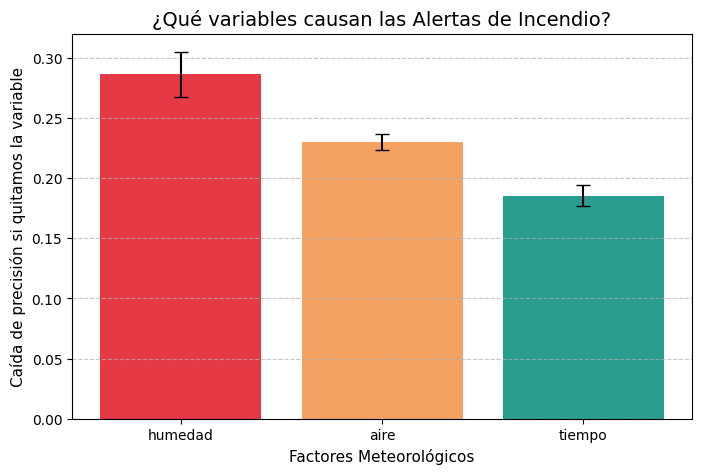

In [48]:
# --- VISUALIZACIÓN GRÁFICA ---
plt.figure(figsize=(8, 5))
plt.bar(df_importancia['Variable'], df_importancia['Importancia_Media'],
        yerr=df_importancia['Desviacion'], capsize=5, color=['#e63946', '#f4a261', '#2a9d8f'])

plt.title('¿Qué variables causan las Alertas de Incendio?', fontsize=14)
plt.ylabel('Caída de precisión si quitamos la variable', fontsize=11)
plt.xlabel('Factores Meteorológicos', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Fase 6: Exportación y Puesta en Producción.

In [ ]:
# ==========================================
# FASE 6: EXPORTACIÓN PARA PRODUCCIÓN
# ==========================================
import joblib

print("--- FASE 6: EMPAQUETANDO EL MODELO ---")

# 1. Guardar el modelo ganador (HistGradientBoosting)
archivo_modelo = 'modelo_incendios_gb.pkl'
joblib.dump(gb_model, archivo_modelo)
print(f"✔️ Modelo guardado exitosamente como: {archivo_modelo}")

# 2. Guardar el Escalador (¡Vital para datos futuros!)
archivo_escalador = 'escalador_incendios.pkl'
joblib.dump(scaler, archivo_escalador)
print(f"✔️ Escalador guardado exitosamente como: {archivo_escalador}")